# 03 — Algoritmos Genéticos: ubicación de hospitales

**Curso:** Inteligencia Artificial — Optimización

Usaremos el mismo problema de Hill Climbing y Simulated Annealing:

> Ubicar varios hospitales en una cuadrícula para minimizar la distancia total de las casas al hospital más cercano.

## Objetivos

- representar una solución mediante un cromosoma;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- comparar el mejor individuo y el fitness medio.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-xu06oxtv because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Problema

Para cada casa $h$, calculamos su distancia al hospital más cercano:

$$
C(H)=
\sum_{h\in\text{casas}}
\min_{p\in H}
d_{\text{Manhattan}}(h,p)
$$

Queremos minimizar $C(H)$.

Como los algoritmos genéticos suelen expresarse como maximización, definimos:

$$
\text{fitness}(H)=-C(H)
$$

Por tanto, un fitness mayor representa una solución de menor costo.

In [ ]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(
        min(manhattan(house, hospital) for hospital in hospitals)
        for house in houses
    )


def fitness(individual, houses):
    return -total_cost(houses, individual)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        rows, cols = zip(*houses)
        ax.scatter(cols, rows, marker="s", s=110, label="Casas")

    if hospitals:
        rows, cols = zip(*hospitals)
        ax.scatter(cols, rows, marker="P", s=180, label="Hospitales")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f"Costo = {total_cost(houses, hospitals)}")
    plt.tight_layout()
    plt.show()

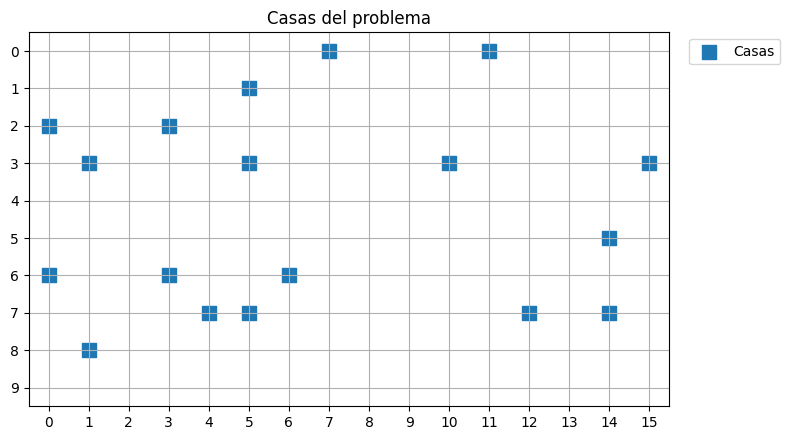

In [ ]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [
    (row, col)
    for row in range(HEIGHT)
    for col in range(WIDTH)
]

rng = random.Random(SEED)

houses = set(rng.sample(all_cells, NUM_HOUSES))
valid_hospital_cells = [
    cell for cell in all_cells
    if cell not in houses
]

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    hospitals=[],
    title="Casas del problema",
)

## 2. Representación del cromosoma

Cada individuo contiene las posiciones de los hospitales:

```python
[(fila_1, columna_1), (fila_2, columna_2), (fila_3, columna_3)]
```

Restricciones de la representación:

- ningún hospital puede ubicarse sobre una casa;
- dos hospitales no pueden ocupar la misma celda.

Individuo: [(3, 8), (7, 6), (1, 9)]
Costo: 87
Fitness: -87


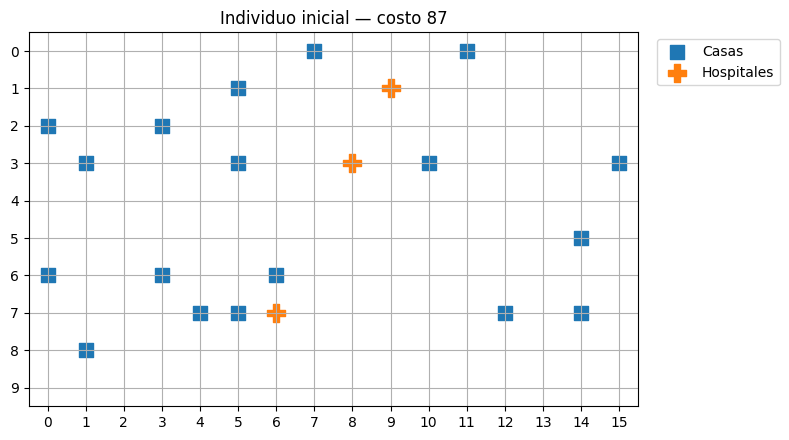

In [ ]:
def create_individual(valid_cells, num_hospitals, rng):
    return rng.sample(valid_cells, num_hospitals)


example = create_individual(
    valid_hospital_cells,
    NUM_HOSPITALS,
    rng,
)

print("Individuo:", example)
print("Costo:", total_cost(houses, example))
print("Fitness:", fitness(example, houses))

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    example,
    title=f"Individuo inicial — costo {total_cost(houses, example)}",
)

## 3. Población inicial

Un algoritmo genético no mantiene una única solución, sino una población de soluciones candidatas.

In [ ]:
def create_population(
    population_size,
    valid_cells,
    num_hospitals,
    rng,
):
    return [
        create_individual(valid_cells, num_hospitals, rng)
        for _ in range(population_size)
    ]


population = create_population(
    population_size=10,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

for i, individual in enumerate(population[:5]):
    print(
        f"{i}: {individual} | "
        f"costo={total_cost(houses, individual)}"
    )

0: [(8, 14), (4, 4), (0, 5)] | costo=71
1: [(4, 13), (9, 7), (7, 7)] | costo=102
2: [(8, 11), (6, 14), (2, 1)] | costo=83
3: [(4, 11), (1, 11), (1, 2)] | costo=88
4: [(6, 15), (6, 13), (1, 14)] | costo=152


## 4. Selección por torneo

Se toman varios individuos al azar y se selecciona el de mayor fitness, es decir, el de menor costo.

In [ ]:
def tournament_selection(
    population,
    houses,
    tournament_size,
    rng,
):
    contestants = rng.sample(
        population,
        tournament_size,
    )

    winner = max(
        contestants,
        key=lambda individual: fitness(individual, houses),
    )

    return winner.copy()


selected = tournament_selection(
    population,
    houses,
    tournament_size=3,
    rng=rng,
)

print("Seleccionado:", selected)
print("Costo:", total_cost(houses, selected))

Seleccionado: [(3, 13), (2, 9), (1, 2)]
Costo: 86


## 5. Cruce de un punto

Cada gen es la posición de un hospital.

Dos padres intercambian parte de sus posiciones. Después del cruce debemos reparar posibles hospitales repetidos.

In [ ]:
def repair_individual(
    individual,
    valid_cells,
    num_hospitals,
    rng,
):
    repaired = []
    used = set()

    for cell in individual:
        if cell in valid_cells and cell not in used:
            repaired.append(cell)
            used.add(cell)

    available = [
        cell for cell in valid_cells
        if cell not in used
    ]

    while len(repaired) < num_hospitals:
        cell = rng.choice(available)
        repaired.append(cell)
        available.remove(cell)

    return repaired[:num_hospitals]


def one_point_crossover(
    parent1,
    parent2,
    crossover_rate,
    valid_cells,
    num_hospitals,
    rng,
):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, num_hospitals - 1)

    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    child1 = repair_individual(
        child1,
        valid_cells,
        num_hospitals,
        rng,
    )
    child2 = repair_individual(
        child2,
        valid_cells,
        num_hospitals,
        rng,
    )

    return child1, child2

In [ ]:
parent1, parent2 = population[0], population[1]

child1, child2 = one_point_crossover(
    parent1,
    parent2,
    crossover_rate=1.0,
    valid_cells=valid_hospital_cells,
    num_hospitals=NUM_HOSPITALS,
    rng=rng,
)

print("Padre 1:", parent1)
print("Padre 2:", parent2)
print("Hijo 1 :", child1)
print("Hijo 2 :", child2)

Padre 1: [(8, 14), (4, 4), (0, 5)]
Padre 2: [(4, 13), (9, 7), (7, 7)]
Hijo 1 : [(8, 14), (4, 4), (7, 7)]
Hijo 2 : [(4, 13), (9, 7), (0, 5)]


## 6. Mutación

La mutación selecciona un hospital y lo mueve a una celda vecina válida.

Esto introduce diversidad y permite explorar configuraciones que no aparecen mediante el cruce.

In [ ]:
def mutate(
    individual,
    mutation_rate,
    height,
    width,
    houses,
    rng,
):
    child = individual.copy()
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for index, hospital in enumerate(child):
        if rng.random() >= mutation_rate:
            continue

        candidates = []

        for dr, dc in moves:
            candidate = (
                hospital[0] + dr,
                hospital[1] + dc,
            )

            if not (
                0 <= candidate[0] < height
                and 0 <= candidate[1] < width
            ):
                continue

            if candidate in houses:
                continue

            if candidate in child:
                continue

            candidates.append(candidate)

        if candidates:
            child[index] = rng.choice(candidates)

    return child

In [ ]:
before = example
after = mutate(
    before,
    mutation_rate=1.0,
    height=HEIGHT,
    width=WIDTH,
    houses=houses,
    rng=rng,
)

print("Antes :", before)
print("Después:", after)
print("Costo antes:", total_cost(houses, before))
print("Costo después:", total_cost(houses, after))

Antes : [(3, 8), (7, 6), (1, 9)]
Después: [(2, 8), (7, 7), (1, 10)]
Costo antes: 87
Costo después: 90


## 7. Algoritmo genético completo

Usaremos:

- selección por torneo;
- cruce de un punto;
- mutación local;
- elitismo: el mejor individuo pasa directamente a la siguiente generación.

In [ ]:
def genetic_algorithm(
    houses,
    valid_cells,
    height,
    width,
    num_hospitals=3,
    population_size=80,
    generations=150,
    crossover_rate=0.9,
    mutation_rate=0.25,
    tournament_size=3,
    elitism=True,
    seed=0,
):
    rng = random.Random(seed)

    population = create_population(
        population_size,
        valid_cells,
        num_hospitals,
        rng,
    )

    history = []

    for generation in range(generations + 1):
        costs = [
            total_cost(houses, individual)
            for individual in population
        ]

        best_index = int(np.argmin(costs))
        best = population[best_index].copy()
        best_cost = costs[best_index]

        history.append({
            "generation": generation,
            "best_cost": best_cost,
            "mean_cost": float(np.mean(costs)),
            "diversity": (
                len({
                    tuple(sorted(individual))
                    for individual in population
                })
                / population_size
            ),
            "best_individual": best,
        })

        if generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(
                population,
                houses,
                tournament_size,
                rng,
            )
            parent2 = tournament_selection(
                population,
                houses,
                tournament_size,
                rng,
            )

            child1, child2 = one_point_crossover(
                parent1,
                parent2,
                crossover_rate,
                valid_cells,
                num_hospitals,
                rng,
            )

            child1 = mutate(
                child1,
                mutation_rate,
                height,
                width,
                houses,
                rng,
            )
            child2 = mutate(
                child2,
                mutation_rate,
                height,
                width,
                houses,
                rng,
            )

            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]["best_individual"], history

Mejor individuo:

 [(2, 4), (4, 13), (7, 3)]
Costo: 56
Fitness: -56
Generaciones: 150


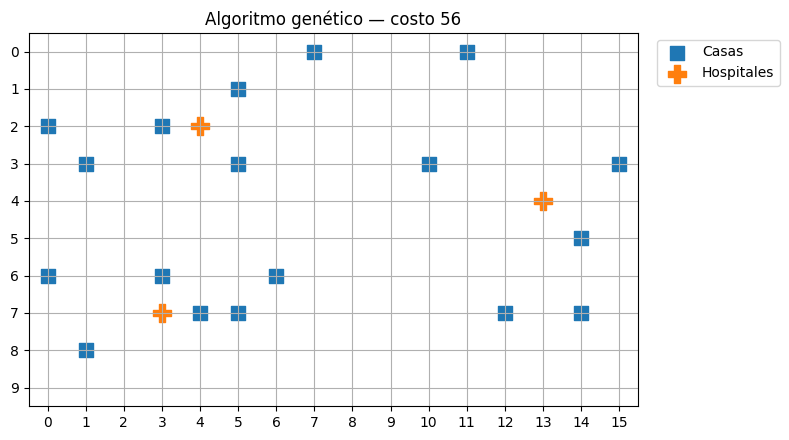

In [ ]:
best, history = genetic_algorithm(
    houses=houses,
    valid_cells=valid_hospital_cells,
    height=HEIGHT,
    width=WIDTH,
    num_hospitals=NUM_HOSPITALS,
    seed=SEED,
)

best_cost = total_cost(houses, best)

print("Mejor individuo:", best)
print("Costo:", best_cost)
print("Fitness:", fitness(best, houses))
print("Generaciones:", history[-1]["generation"])

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    best,
    title=f"Algoritmo genético — costo {best_cost}",
)

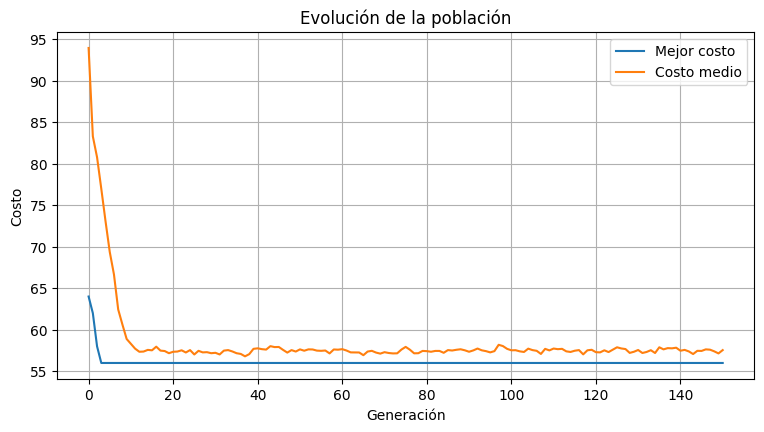

In [ ]:
generations = [
    record["generation"]
    for record in history
]
best_costs = [
    record["best_cost"]
    for record in history
]
mean_costs = [
    record["mean_cost"]
    for record in history
]

plt.figure(figsize=(9, 4.5))
plt.plot(
    generations,
    best_costs,
    label="Mejor costo",
)
plt.plot(
    generations,
    mean_costs,
    label="Costo medio",
)
plt.xlabel("Generación")
plt.ylabel("Costo")
plt.title("Evolución de la población")
plt.legend()
plt.grid(True)
plt.show()

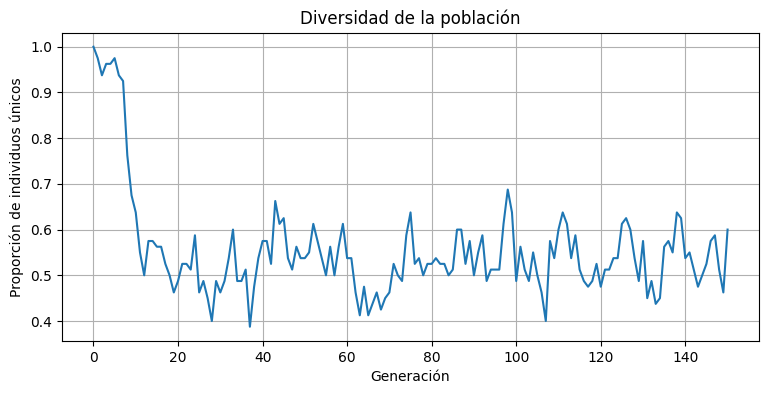

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(
    generations,
    [record["diversity"] for record in history],
)
plt.xlabel("Generación")
plt.ylabel("Proporción de individuos únicos")
plt.title("Diversidad de la población")
plt.grid(True)
plt.show()

## 8. Efecto de la mutación

Una mutación muy baja puede producir convergencia prematura.

Una mutación muy alta puede impedir que la población conserve buenas configuraciones.

In [ ]:
mutation_rates = [0.0, 0.05, 0.15, 0.30, 0.70]
summary = []

for rate in mutation_rates:
    final_costs = []

    for seed in range(15):
        solution, _ = genetic_algorithm(
            houses=houses,
            valid_cells=valid_hospital_cells,
            height=HEIGHT,
            width=WIDTH,
            num_hospitals=NUM_HOSPITALS,
            population_size=60,
            generations=100,
            mutation_rate=rate,
            seed=seed,
        )

        final_costs.append(
            total_cost(houses, solution)
        )

    summary.append({
        "mutation_rate": rate,
        "mean_cost": np.mean(final_costs),
        "best_cost": min(final_costs),
        "std_cost": np.std(final_costs),
    })

for row in summary:
    print(row)

{'mutation_rate': 0.0, 'mean_cost': np.float64(58.666666666666664), 'best_cost': 56, 'std_cost': np.float64(1.813529401164726)}
{'mutation_rate': 0.05, 'mean_cost': np.float64(56.333333333333336), 'best_cost': 56, 'std_cost': np.float64(0.5962847939999438)}
{'mutation_rate': 0.15, 'mean_cost': np.float64(56.06666666666667), 'best_cost': 56, 'std_cost': np.float64(0.24944382578492943)}
{'mutation_rate': 0.3, 'mean_cost': np.float64(56.0), 'best_cost': 56, 'std_cost': np.float64(0.0)}
{'mutation_rate': 0.7, 'mean_cost': np.float64(56.0), 'best_cost': 56, 'std_cost': np.float64(0.0)}


# Actividades

## Actividad 1 — Mutación global

Modifica `mutate()` para que un hospital pueda moverse a cualquier celda válida, no solamente a una celda vecina.

Compara:

- velocidad de convergencia;
- costo final;
- diversidad.

In [ ]:
# TODO: implementa mutate_global(...)

## Actividad 2 — Cruce uniforme

Para cada hospital, el hijo recibe la posición del padre 1 o del padre 2 con igual probabilidad.

Recuerda reparar hospitales repetidos.

In [ ]:
# TODO: implementa uniform_crossover(...)

## Actividad 3 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo.

Pregunta:

> ¿Puede aumentar el mejor costo de una generación a la siguiente cuando no usamos elitismo?

In [ ]:
# TODO: compara elitism=True y elitism=False

## Actividad 4 — Comparación

Compara, usando las mismas casas:

- Hill Climbing;
- Simulated Annealing;
- Algoritmo Genético.

Realiza varias corridas y reporta:

- costo medio;
- mejor costo;
- desviación estándar;
- tiempo de ejecución.

## Preguntas de cierre

1. ¿Qué representa un gen en este problema?
2. ¿Qué representa un cromosoma?
3. ¿Por qué el cruce puede producir hospitales repetidos?
4. ¿Qué función cumple la reparación?
5. ¿Qué parámetros controlan exploración y explotación?
6. ¿Qué ventaja aporta mantener una población frente a Hill Climbing?